Numerical Results

In this section, we calculate the current density due to SEI for all models with the following parameters:

In [3]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

# Stadardised Formation Cycling Bham group
# no_cycles = 1
# exp = pybamm.Experiment( [("Charge at C/20 until 4.2 V",
#                            "Hold at 4.2 V for 1 hours", 
#                            "Hold at 4.2 V until 2.5 mA", 
#                            "Discharge at C/20 until 2.5 V",
#                            "Charge at C/20 until 3.8 V",
#                            "Hold at 3.8 V for 1 hours"
#                            )]* no_cycles)

no_cycles = 1
exp = pybamm.Experiment(
    [(
      "Charge at C/20 until 4.2 V",
       "Rest for 5 hour",
      "Discharge at C/20 until 2.5 V",
      "Rest for 5 hour",
      )]* no_cycles )
# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed


sei_options = ["Kolzenberg2020", "interstitial-diffusion limited", "electron-migration limited"]
# sei_options = [ "Kolzenberg2020"
#                 ]
effective_param=[0, 0, 0]
params = []
for i in range(0, len(effective_param)):
  param=pybamm.ParameterValues("Chen2020")
  param['Initial inner SEI thickness [m]']=5e-13
  param['Initial outer SEI thickness [m]']=5e-13
  param['SEI kinetic rate constant [m.s-1]'] =1.0e-18
  param['Outer SEI solvent diffusivity [m2.s-1]' ]=2.5e-22
  param['Bulk solvent concentration [mol.m-3]']= 4541.0
  # param['Inner SEI open-circuit potential [V]']=0.4
  # param['Outer SEI open-circuit potential [V]']=0.4
  param['SEI open-circuit potential [V]'] = 1.1054311043614184
  param['Inner SEI electron conductivity [S.m-1]']=8.95e-16
  param['SEI lithium ion conductivity [S.m-1]']=1e-8
  param['Inner SEI lithium interstitial diffusivity [m2.s-1]']=1e-18
  param['Lithium interstitial reference concentration [mol.m-3]']=15
  # param['Upper voltage cut-off [V]']=1.2
  # param['Lower voltage cut-off [V]']=0.1
  # param['Open-circuit voltage at 0% SOC [V]'] =0.1
  # param['Open-circuit voltage at 100% SOC [V]'] =1.2
  # param['Nominal cell capacity [A.h]']= 1.2
  # This has been used in Kolzenberg model 
  param['SEI reaction exchange current density [A.m-2]'] =1.5e-7
  params.append(param)

# param


/home/kawamanmi/Projects/PyBaMM


In [4]:
models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
                                  "SEI": sei_option}) for sei_option in sei_options]


pybamm.settings.max_y_value = 100000000
solver = pybamm.CasadiSolver(mode="safe")

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]

In [5]:
# models[0].variable_names()

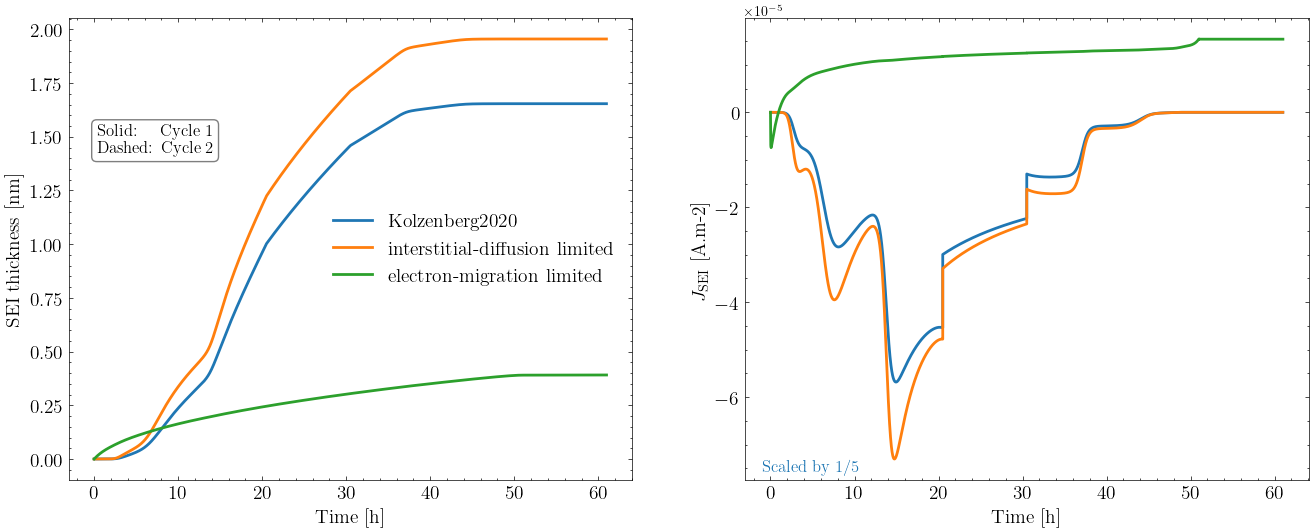

In [6]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm
import matplotlib.ticker as ticker
plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)

# plt.rcParams["font.family"] = "DejaVu Sans"

# linestyles = ["-", "--", "-.", ":", "-"]
line_styles = ["-", "--"]
# colors = ['darkred', 'darkblue', 'red',  'blue', 'lightcoral', 'lightblue']
# index_color = 0
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# First plot
for index, sol in enumerate(sols):
    for cycle in range(no_cycles):
        t_min = np.min(sol.cycles[cycle]["Time [h]"].entries)
        t = sol.cycles[cycle]["Time [h]"].entries-t_min
        L_min = np.min(
            sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries)
        L_sei = (
            sol.cycles[cycle]['X-averaged negative total SEI thickness [m]'].entries-L_min)*1e9
        if (index == 0):
            L_sei = L_sei*1
        if (cycle == 0):
            axs[0].plot(t, L_sei,
                        label=str(sei_options[index]),
                        linestyle=line_styles[0], linewidth=2, color=cmap(index))
        else:
            axs[0].plot(t, L_sei,
                        linestyle=line_styles[1], linewidth=2, color=cmap(index))

axs[0].legend(fontsize=14)
axs[0].set_xlabel("Time [h]", fontsize=14)
axs[0].set_ylabel("SEI thickness [nm]", fontsize=14)
axs[0].tick_params(axis='both', which='major', labelsize=14)
axs[0].text(0.05, 0.7, 'Solid:  \  \ \ Cycle 1\nDashed: Cycle 2',
            transform=axs[0].transAxes, fontsize=12,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Second plot
index_color = 0
for index, sol in enumerate(sols):
    for cycle in range(no_cycles):
        t_min = np.min(sol.cycles[cycle]["Time [h]"].entries)
        t = sol.cycles[cycle]["Time [h]"].entries-t_min
        J_sei_last = sol.cycles[cycle]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries[0]
        J_sei = (
            sol.cycles[cycle]['X-averaged negative electrode SEI interfacial current density [A.m-2]'].entries - J_sei_last)
        # if (cycle == 0 and index == 0):
        #     J_sei = J_sei/5
        axs[1].plot(t,
                    J_sei,
                    linestyle=line_styles[cycle % 2], linewidth=2, color=cmap(index))

# axs[1].legend(fontsize=14)
axs[1].set_xlabel("Time [h]", fontsize=14)
axs[1].set_ylabel(
    "$J_\mathrm{SEI}$ [A.m-2] ", fontsize=14)
axs[1].tick_params(axis='both', which='major', labelsize=14)
# Add text to the second subplot
axs[1].text(0.03, 0.02, 'Scaled by 1/5',
            transform=axs[1].transAxes, fontsize=12, color=cmap(0),)

# plt.tight_layout()
# plt.savefig("figure2.pdf", format='pdf', dpi=300)
plt.show()

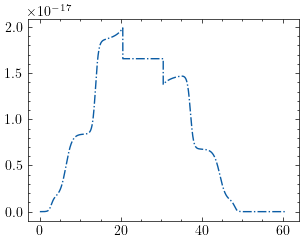

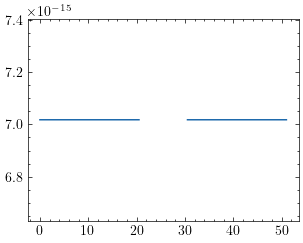

In [7]:
# Finding mode of Kolzenberg model
D_li = 1e-22
C_li_0 = 1000
F = 96485
R = 8.314
T = 303
jsei_0_0 = 100
kappa_Li_ion = 1e-14
U_sei = 0.8
k = 0
alpha_sei = 0.5
Ocv_n = sols[k]['X-averaged negative electrode open-circuit potential [V]'].entries
j_int = sols[k]['X-averaged negative electrode total interfacial current density [A.m-2]'].entries
eta_sei = sols[k]['X-averaged negative electrode reaction overpotential [V]'].entries
delta_phi = sols[k]['X-averaged negative electrode surface potential difference [V]'].entries
t = sols[k]['Time [h]'].entries
# plt.plot(t, eta_sei + Ocv_n, "--", color="blue")
# plt.plot(t, delta_phi, "-", color="red")
# plt.show()
# cs = np.linspace(0, 3160, len(j_int))
# U0 = ((1.24-cs/3160)/1.16)**2.92
L_diff = F * D_li * C_li_0 / jsei_0_0 * \
    np.exp(-(1-alpha_sei) * F/(R*T) * (delta_phi))
plt.plot(t, L_diff, "-.")
plt.show()

L_mig = 2 * R*T * kappa_Li_ion / (F * (np.abs(j_int)))
plt.plot(t, L_mig, "-")
# # L_mig = np.where(j_int != 0, 2 * R*T * kappa_Li_ion / (F * np.abs(j_int)), 0)
# # L_mig = np.where(np.abs(j_int) > 1e-4, 2 * R*T *
# #                  kappa_Li_ion / (F * np.abs(j_int)), 0)
# L_app = sols[k]['X-averaged negative total SEI thickness [m]'].entries
# t = sols[k]['Time [h]'].entries

# # plt.plot(t, L_app, "--")
# plt.plot(t, L_diff, "-.")
# plt.show()
# plt.plot(t, L_mig, "-")
# plt.show()
# # plt.plot(t, L_app, "--")

# # plt.plot(t, eta_sei*1, "--", color="blue")
# # plt.plot(t, delta_phi, "-", color="red")
# # plt.plot(t, Ocv_n, "-.")
# plt.plot(t, j_int, "--", color="blue")
# print(Ocv_n[0])

In [8]:
jse2 = F**2 * D_li * C_li_0 / (2*R*T * kappa_Li_ion) * np.exp(-F/(R*T)*0.1)
print(jse2)

0.40110400851709455


In [9]:
# j0 = sols[k]['X-averaged negative electrode exchange current density [A.m-2]'].entries
# j0 = jsei_0_0*np.sqrt()
# j_int2 = 2*j0*np.sinh(alpha_sei*F/(2*R*T)*eta_sei)
# plt.plot(t, j_int2,  color="red", marker="o",  linestyle='none')

In [10]:
L_mig2 = 2 * R*T / F
print(L_mig2)

L_diff2 = F**2 * D_li * C_li_0 / (2*R*T*kappa_Li_ion) * np.exp(-F/(R*T))
print(L_diff2)

0.052218313727522406
4.293756381954859e-16


In [11]:
# plt.plot(sols[k]['Time [h]'].entries, sols[k]
#          ['X-averaged negative total SEI thickness [m]'].entries*1e9)
# plt.plot(t, delta_phi, "-", color="red")

In [12]:
# plt.plot(sols[k]['Time [h]'].entries, sols[2]
#          ['Average negative particle concentration [mol.m-3]'].entries, "-.")
# c_s = sols[k]['Average negative particle concentration [mol.m-3]'].entries

# c_e = sols[k]['X-averaged negative electrolyte concentration [mol.m-3]'].entries

In [13]:
# j0 = []
# for i in range(0, len(c_e)):
#     j0.append(params[2]['Negative electrode exchange-current density [A.m-2]'](
#         c_e[i], c_s[i], 30000, 303).value)

# plt.plot(sols[k]['Time [h]'].entries, j0, "-.")

In [14]:
# 'Total current density [A.m-2]'
# plt.plot(sols[2]['Time [h]'].entries, sols[2]
#          ['Total current density [A.m-2]'].entries, "-.")
# plt.plot(sols[k]['Time [h]'].entries, sols[k]
#          ['X-averaged negative electrode total interfacial current density [A.m-2]'].entries, "-.")